Select:  Weather_Data_All.csv


Saving Weather_Data_All.csv to Weather_Data_All (2).csv
Uploaded: ['Weather_Data_All (2).csv']
TensorFlow : 2.20.0
GPU NOT found → Runtime → Change runtime type → T4 GPU
Config ready.
Architecture : BiLSTM(64) + BiLSTM(32) + Dense(16) + Dense(96)
Input  : 96  × 15-min steps  = 24h of weather features
Output : 96 × 15-min steps  = full next-day irradiance
This eliminates autoregressive error, artificial sunset masking,
and peak-time drift — the model learns the full curve from training data.
Dropped 24 invalid dates (e.g. 2023-02-29).
Raw data : 17760 hourly rows
Span     : 2022-12-01 00:00:00  →  2024-12-10 23:00:00
Irradiance — max: 1007.6  mean(day): 380.8 W/m²
After resample : 71133 rows at 15-min resolution
Feature engineering complete : (71129, 11)
Train : 56903 rows  (2022-12-01 01:00:00  →  2024-07-15 18:30:00)
Val   : 7113  rows  (2024-07-15 18:45:00  →  2024-09-27 20:45:00)
Test  : 7113 rows  (2024-09-27 21:00:00  →  2024-12-10 23:00:00)
Irradiance scaler : 0.0 – 1007.6 W/m²
t

Model: "Solar_BiLSTM_Direct96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 96, 128)        │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │         1,632 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,800 (323.44 KB)

 Trainable params: 82,800 (323.44 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters : 82,800
Output shape     : (96,) — full next-day irradiance in one pass
Training...
With T4 GPU : 10-20 min  |  Without GPU : 60-90 min
Epoch 1/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 206s 222ms/step - loss: 0.0168 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 2/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 185s 208ms/step - loss: 0.0064 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 3/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 194s 199ms/step - loss: 0.0059 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 192s 216ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 5/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 197s 210ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 6/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 179s 202ms/step - loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 7/50
887/887 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: nan
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
887/887 ━━━━━━━━━━━━━━━━━━━━ 187s 211

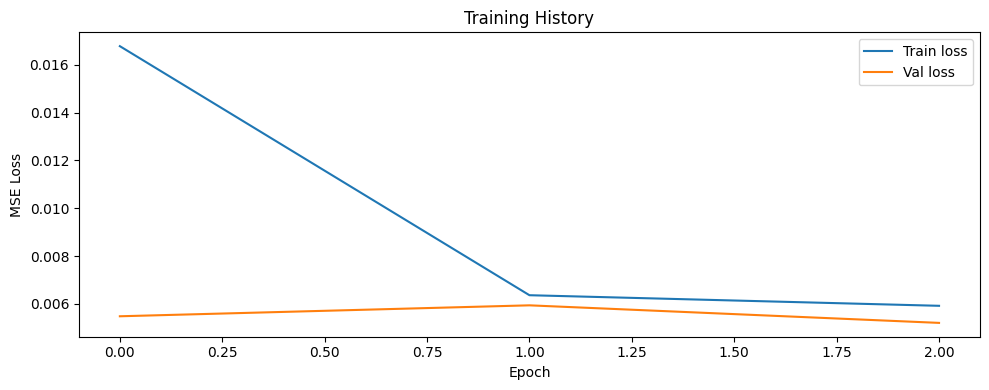

In [ ]:
# =============================================================================
#  SOLAR NOTEBOOK 1 — TRAIN AND SAVE  (direct 96-step output)
#
#  KEY ARCHITECTURAL CHANGE vs previous versions:
#    OLD: model outputs 1 value → needed 96 autoregressive calls in NB2
#         → error compounds, peak time drifts, needs artificial sunset mask
#    NEW: model outputs 96 values at once (full next day in one forward pass)
#         → no error accumulation, no autoregressive loop, no artificial mask
#         → same architecture as the working load forecasting model
#
#  HOW IT WORKS:
#    Input  : 96 rows of yesterday's actual weather (24h × 15-min)
#    Output : 96 irradiance values for tomorrow    (24h × 15-min)
#    The model learns the full bell curve shape from training data.
#    No post-processing tricks needed.
#
#  SPEED:
#    With T4 GPU : 10-20 min  →  Runtime → Change runtime type → T4 GPU
#    Without GPU : 60-90 min
#
#  INPUT:  Weather_Data_All.csv
#  OUTPUT: saved_solar_model.zip
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Upload historical weather CSV
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files as colab_files
print('Select:  Weather_Data_All.csv')
uploaded = colab_files.upload()
print('Uploaded:', list(uploaded.keys()))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os, pickle, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from google.colab import files as colab_files

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
if gpus:
    print(f'GPU : {gpus}  ✓  (10-20 min training)')
else:
    print('GPU NOT found → Runtime → Change runtime type → T4 GPU')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Configuration
# ─────────────────────────────────────────────────────────────────────────────
HIST_CSV    = 'Weather_Data_All.csv'
MODEL_DIR   = 'saved_solar_model'
EVAL_DIR    = 'Solar_Evaluation'

N_PAST      = 96     # input  : 96 × 15-min = 24h of yesterday's weather
N_FUTURE    = 96     # output : 96 × 15-min = 24h of tomorrow's irradiance

TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
EPOCHS      = 50
BATCH_SIZE  = 64
LR          = 0.001

FEATURES = ['Irradiance', 'Temp', 'Humidity', 'WindSpeed', 'CloudCover',
            'Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos', 'Irr_lag1', 'Irr_lag4']

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,  exist_ok=True)

print('Config ready.')
print(f'Architecture : BiLSTM(64) + BiLSTM(32) + Dense(16) + Dense({N_FUTURE})')
print(f'Input  : {N_PAST}  × 15-min steps  = 24h of weather features')
print(f'Output : {N_FUTURE} × 15-min steps  = full next-day irradiance')
print(f'This eliminates autoregressive error, artificial sunset masking,')
print(f'and peak-time drift — the model learns the full curve from training data.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Load and feature-engineer the historical data
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv(HIST_CSV)

# Parse ISO 8601 dates, drop invalid (e.g. 2023-02-29 — not a leap year)
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601', errors='coerce')
bad = df['Date'].isna().sum()
if bad > 0:
    print(f'Dropped {bad} invalid dates (e.g. 2023-02-29).')
    df = df.dropna(subset=['Date'])

df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.rename(columns={
    'Solar radiation': 'Irradiance',
    'Temperature'    : 'Temp',
    'Humidity'       : 'Humidity',
    'Wind speed'     : 'WindSpeed',
    'Cloud cover'    : 'CloudCover',
}, inplace=True)

print(f'Raw data : {len(df)} hourly rows')
print(f'Span     : {df.index[0]}  →  {df.index[-1]}')
print(f'Irradiance — max: {df["Irradiance"].max():.1f}  '
      f'mean(day): {df[df["Irradiance"]>0]["Irradiance"].mean():.1f} W/m²')

# Resample hourly → 15-min
df_15 = df.resample('15min').interpolate(method='linear')
print(f'After resample : {len(df_15)} rows at 15-min resolution')

# Cyclic time features — encode time-of-day and day-of-year continuously
# sin/cos ensures 23:45 and 00:00 are close, not far apart as integers
df_15['Hour']        = df_15.index.hour + df_15.index.minute / 60
df_15['Hour_sin']    = np.sin(2 * np.pi * df_15['Hour'] / 24)
df_15['Hour_cos']    = np.cos(2 * np.pi * df_15['Hour'] / 24)
df_15['Day_of_Year'] = df_15.index.dayofyear
df_15['Day_sin']     = np.sin(2 * np.pi * df_15['Day_of_Year'] / 365.25)
df_15['Day_cos']     = np.cos(2 * np.pi * df_15['Day_of_Year'] / 365.25)

# Lag features — give model recent irradiance history
df_15['Irr_lag1'] = df_15['Irradiance'].shift(1)   # 15 min ago
df_15['Irr_lag4'] = df_15['Irradiance'].shift(4)   # 1 hour ago
df_15.dropna(inplace=True)

df_final   = df_15[FEATURES]
n_features = len(FEATURES)
print(f'Feature engineering complete : {df_final.shape}')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Split and scale  (scaler fitted on train only — no leakage)
# ─────────────────────────────────────────────────────────────────────────────
n     = len(df_final)
n_tr  = int(n * TRAIN_RATIO)
n_val = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df_final.iloc[:n_tr]
df_val   = df_final.iloc[n_tr:n_val]
df_test  = df_final.iloc[n_val:]

print(f'Train : {len(df_train)} rows  ({df_train.index[0]}  →  {df_train.index[-1]})')
print(f'Val   : {len(df_val)}  rows  ({df_val.index[0]}  →  {df_val.index[-1]})')
print(f'Test  : {len(df_test)} rows  ({df_test.index[0]}  →  {df_test.index[-1]})')

scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(df_train.values)
val_scaled   = scaler.transform(df_val.values)
test_scaled  = scaler.transform(df_test.values)

print(f'Irradiance scaler : {scaler.data_min_[0]:.1f} – {scaler.data_max_[0]:.1f} W/m²')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Build sequences  (96 input steps → 96 output steps)
#
#  Each sequence:
#    X[i] = scaled weather features for 24h window
#    Y[i] = scaled irradiance for the NEXT 24h (all 96 steps at once)
#
#  This is the key change vs the old model which only predicted Y[i] = 1 value.
#  The model now learns the full diurnal irradiance pattern directly from
#  training data — no autoregressive loop needed at inference time.
# ─────────────────────────────────────────────────────────────────────────────
def create_sequences(data, n_past, n_future):
    X, Y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])          # (96, 11) — all features
        Y.append(data[i:i + n_future, 0])        # (96,) — irradiance only
    return np.array(X), np.array(Y)

trainX, trainY = create_sequences(train_scaled, N_PAST, N_FUTURE)
valX,   valY   = create_sequences(val_scaled,   N_PAST, N_FUTURE)
testX,  testY  = create_sequences(test_scaled,  N_PAST, N_FUTURE)

print(f'trainX: {trainX.shape}   trainY: {trainY.shape}')
print(f'valX  : {valX.shape}     valY  : {valY.shape}')
print(f'testX : {testX.shape}    testY : {testY.shape}')
print(f'\ntrainY shape {trainY.shape} confirms 96-step output per sequence.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Build model
#
#  Output layer: Dense(96) — predicts all 96 irradiance steps at once.
#  This is the same direct-output approach used in the load forecasting model
#  which correctly produces full-day forecasts without post-processing.
# ─────────────────────────────────────────────────────────────────────────────
model = Sequential([
    Bidirectional(LSTM(64, activation='relu', return_sequences=True),
                  input_shape=(N_PAST, n_features)),
    Dropout(0.1),
    Bidirectional(LSTM(32, activation='relu')),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(N_FUTURE),    # outputs all 96 irradiance values at once
], name='Solar_BiLSTM_Direct96')

model.compile(optimizer=Adam(learning_rate=LR), loss='mse')
model.summary()
print(f'\nTotal parameters : {model.count_params():,}')
print(f'Output shape     : ({N_FUTURE},) — full next-day irradiance in one pass')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Train
# ─────────────────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-5, verbose=1),
]

print('Training...')
print('With T4 GPU : 10-20 min  |  Without GPU : 60-90 min')

history = model.fit(
    trainX, trainY,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = (valX, valY),
    callbacks       = callbacks,
    verbose         = 1,
)

print(f'\nStopped at epoch {len(history.history["loss"])}')
print(f'Best val_loss  : {min(history.history["val_loss"]):.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend(); plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/training_history.png', dpi=150)
plt.show()




In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Evaluate on test set
# ─────────────────────────────────────────────────────────────────────────────
pred_scaled = model.predict(testX, verbose=0)   # (N, 96)

# Inverse transform: expand each prediction to full feature width, then extract
def inverse_irr(scaled_arr, scaler, n_features):
    """Inverse-transform a (N, 96) scaled irradiance array back to W/m²."""
    N, steps = scaled_arr.shape
    out = np.zeros((N * steps, n_features))
    out[:, 0] = scaled_arr.reshape(-1)
    return scaler.inverse_transform(out)[:, 0].reshape(N, steps)

y_pred   = inverse_irr(pred_scaled, scaler, n_features)
y_actual = inverse_irr(testY,       scaler, n_features)

# Flatten for global metrics
yp_flat = y_pred.reshape(-1)
ya_flat = y_actual.reshape(-1)

mse  = mean_squared_error(ya_flat, yp_flat)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(ya_flat, yp_flat)
r2   = r2_score(ya_flat, yp_flat)

print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.4f} W/m²')
print(f'MAE  : {mae:.4f} W/m²')
print(f'MSE  : {mse:.4f}')
print(f'\nPrediction range : {yp_flat.min():.1f} – {yp_flat.max():.1f} W/m²')
print(f'Actual range     : {ya_flat.min():.1f} – {ya_flat.max():.1f} W/m²')

if yp_flat.max() < 200:
    print('\nWARNING: Prediction max < 200 W/m² — model may be underfitting.')
else:
    print(f'\nModel looks good — max prediction {yp_flat.max():.1f} W/m² is realistic.')




R²   : 0.9054
RMSE : 79.3189 W/m²
MAE  : 45.5224 W/m²
MSE  : 6291.4849

Prediction range : -73.0 – 942.1 W/m²
Actual range     : 0.0 – 900.1 W/m²

Model looks good — max prediction 942.1 W/m² is realistic.


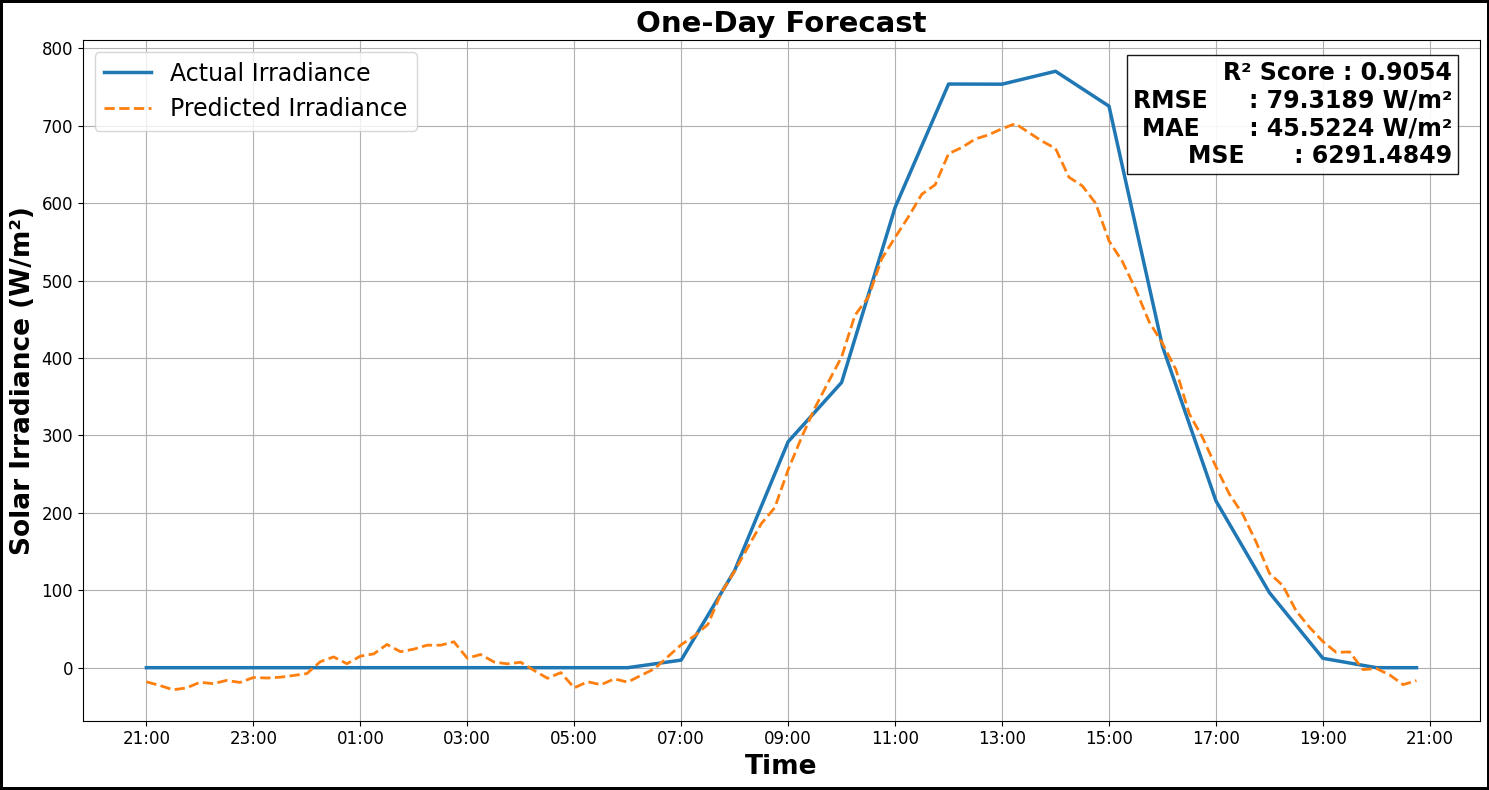

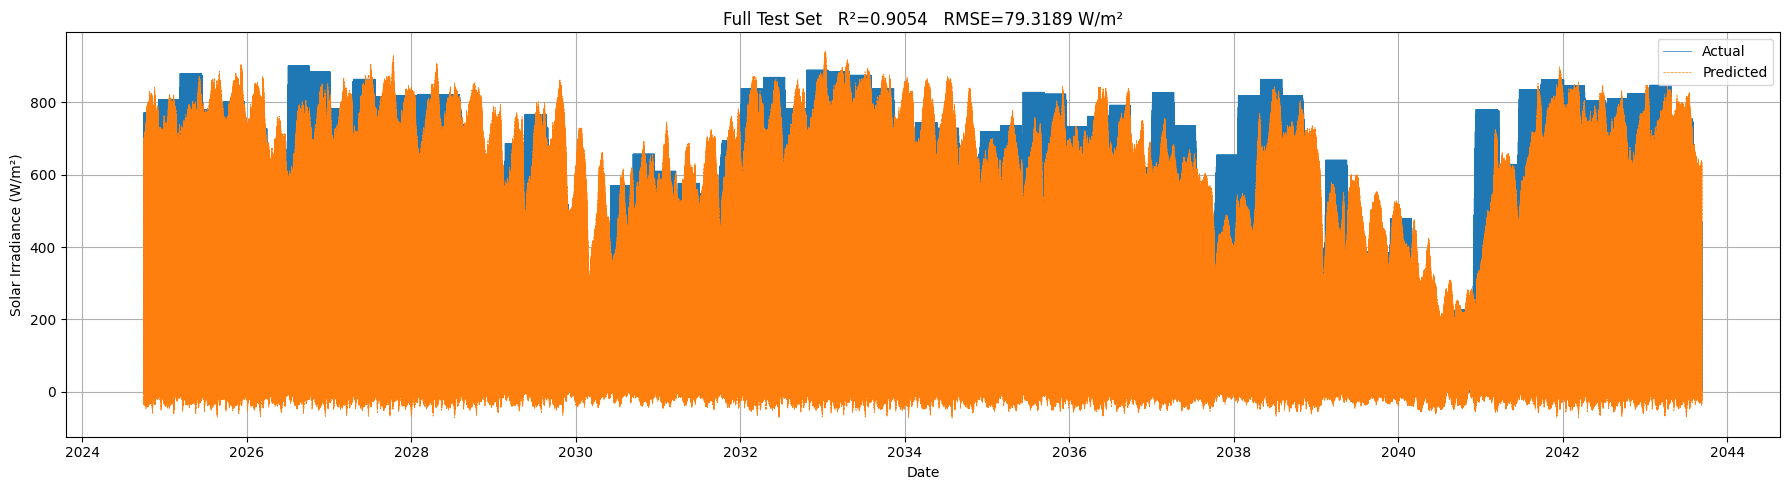

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Evaluation plots (Corrected for Direct 96-step Model)
# ─────────────────────────────────────────────────────────────────────────────

# Choose one prediction sequence (one complete forecast day)
sample_idx = 0

daily_actual = y_actual[sample_idx]
daily_pred = y_pred[sample_idx]

# Create correct 96 timestamps for this forecast day
start_time = df_test.index[N_PAST + sample_idx]
time_index = pd.date_range(start=start_time,
                           periods=N_FUTURE,
                           freq='15min')

daily_view = pd.DataFrame({
    'Actual': daily_actual,
    'Predicted': daily_pred
}, index=time_index)

# ---------------- Daily Plot ----------------
fig, ax = plt.subplots(figsize=(15,8))

ax.plot(daily_view.index,
        daily_view['Actual'],
        label='Actual Irradiance',
        linewidth=2.5)

ax.plot(daily_view.index,
        daily_view['Predicted'],
        '--',
        linewidth=2,
        label='Predicted Irradiance')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

stats_box = (
    f'R² Score : {r2:.4f}\n'
    f'RMSE     : {rmse:.4f} W/m²\n'
    f'MAE      : {mae:.4f} W/m²\n'
    f'MSE      : {mse:.4f}'
)

ax.text(0.98,0.97,
        stats_box,
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=17,
        fontweight='bold',
        bbox=dict(facecolor='white',
                  alpha=0.9))

ax.set_xlabel('Time',fontsize=19, fontweight='bold')
ax.set_ylabel('Solar Irradiance (W/m²)',fontsize=19, fontweight='bold')
ax.set_title('One-Day Forecast',fontsize=21, fontweight='bold')
ax.grid(True)
ax.legend(fontsize=17)

# Increase axis value (tick) size and make bold
plt.setp(ax.get_xticklabels(), fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=12)


# ---- Add black frame to entire figure ----
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(4)

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/solar_evaluation_daily.png', dpi=150)
plt.show()


# ---------------- Full Test Set Plot ----------------
# Flatten predictions using sequential timestamps

n_sequences = y_actual.shape[0]

full_actual = y_actual.reshape(-1)
full_pred = y_pred.reshape(-1)

full_index = pd.date_range(
    start=df_test.index[N_PAST],
    periods=len(full_actual),
    freq='15min'
)

fig2, ax2 = plt.subplots(figsize=(18,5))

ax2.plot(full_index,
         full_actual,
         linewidth=0.5,
         label='Actual')

ax2.plot(full_index,
         full_pred,
         '--',
         linewidth=0.5,
         label='Predicted')

ax2.set_xlabel('Date')
ax2.set_ylabel('Solar Irradiance (W/m²)')
ax2.set_title(f'Full Test Set   R²={r2:.4f}   RMSE={rmse:.4f} W/m²')

ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/solar_evaluation_full.png', dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Save to pickle
# ─────────────────────────────────────────────────────────────────────────────
with open(f'{MODEL_DIR}/solar_model.pkl', 'wb') as f:
    pickle.dump({
        'weights'      : model.get_weights(),
        'model_config' : model.get_config(),
        'n_past'       : N_PAST,
        'n_future'     : N_FUTURE,
        'n_features'   : n_features,
    }, f)

with open(f'{MODEL_DIR}/solar_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open(f'{MODEL_DIR}/solar_meta.pkl', 'wb') as f:
    pickle.dump({
        'features'       : FEATURES,
        'irradiance_col' : 0,
        'n_past'         : N_PAST,
        'n_future'       : N_FUTURE,
        'n_features'     : n_features,
        'model_type'     : 'direct_96',   # marks this as direct-output model
        'metrics'        : {
            'mse' : float(mse),
            'rmse': float(rmse),
            'mae' : float(mae),
            'r2'  : float(r2),
        },
    }, f)

print(f'Pickle files saved → {MODEL_DIR}/')
for fn in ['solar_model.pkl', 'solar_scaler.pkl', 'solar_meta.pkl']:
    size = os.path.getsize(f'{MODEL_DIR}/{fn}')
    print(f'  {fn}  ({size:,} bytes)')
print(f'\nR² = {r2:.4f}   RMSE = {rmse:.4f} W/m²')
print(f'Model type: direct_96  (single forward pass → 96 output values)')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Download ZIP
# ─────────────────────────────────────────────────────────────────────────────
shutil.make_archive('saved_solar_model', 'zip', MODEL_DIR)
print('Downloading saved_solar_model.zip ...')
colab_files.download('saved_solar_model.zip')
print('\nDone. Upload this ZIP in Notebook 2 every day. Never retrain.')

Pickle files saved → saved_solar_model/
  solar_model.pkl  (335,266 bytes)
  solar_scaler.pkl  (922 bytes)
  solar_meta.pkl  (308 bytes)

R² = 0.9054   RMSE = 79.3189 W/m²
Model type: direct_96  (single forward pass → 96 output values)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. Upload this ZIP in Notebook 2 every day. Never retrain.
